# Metacognitive Calibration: Do Confidence and Anxiety Accurately Track Outcomes?

**Reframe:** Instead of asking "does the model predict how you feel?", ask:
1. **Calibration accuracy:** Does rated confidence predict actual escape? Does anxiety predict capture?
2. **Calibration by condition:** Are people better calibrated at extreme vs ambiguous threat?
3. **Individual differences in calibration:** Does z (distance-dependent threat differentiation) predict metacognitive accuracy?
4. **Anxiety as threat-effort signal:** Does anxiety accurately reflect the objective challenge?

**Data structure:**
- Probe trials: forced-choice (identical options), participant rates anxiety or confidence (0-7 scale)
- Probe trials have their own threat/distance/effort conditions
- Behavioral trials: actual foraging with escape/capture outcomes
- Link probes to following behavioral trial for outcome prediction

In [10]:
# ── SETUP ─────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

ROOT = Path('/Users/nokada/Desktop/EffortForagingUnderThreat')
DATA_DIR = ROOT / 'data' / 'exploratory_350' / 'processed'
STAGE5 = DATA_DIR / 'stage5_filtered_data_20260317_094210'
VIGOR_PROC = DATA_DIR / 'vigor_processed'
STATS_DIR = ROOT / 'results' / 'stats'
FIGS_DIR = ROOT / 'figs'

DPI = 150
plt.style.use('seaborn-v0_8-whitegrid')

# ── Load probe ratings ──
feelings = pd.read_csv(STAGE5 / 'feelings.csv')
print(f'Probe ratings: {feelings.shape}')
print(f'Columns: {feelings.columns.tolist()[:10]}')

# Standardize column names
feelings = feelings.rename(columns={
    'attackingProb': 'p_threat',
    'questionLabel': 'affect_type',
    'response': 'rating',
    'trialNumber': 'event_idx',
    'distanceFromSafety': 'dist_safety',
})

print(f'\nAffect types: {feelings["affect_type"].value_counts().to_dict()}')
print(f'Rating range: {feelings["rating"].min()} - {feelings["rating"].max()}')
print(f'Threat levels in probes: {sorted(feelings["p_threat"].unique())}')

# ── Load model parameters ──
param_df = pd.DataFrame({
    p: pd.read_csv(STATS_DIR / f'FET_Exp_Bias_{p}_params.csv').rename(columns={'subject':'subj'}).set_index('subj')['median']
    for p in ['z','k','beta']
})
param_df.columns = ['z', 'kappa', 'beta']
for c in param_df.columns:
    param_df[f'{c}_z'] = (param_df[c] - param_df[c].mean()) / param_df[c].std()

print(f'\nModel params: {len(param_df)} subjects')

Probe ratings: (10546, 16)
Columns: ['attackingProb', 'questionType', 'response', 'trialNumber', 'category', 'trialCookie_rewardValue', 'trialCookie_time', 'trialCookie_weight', 'trialCookie_xPos', 'trialCookie_yPos']

Affect types: {'anxiety': 5274, 'confidence': 5272}
Rating range: 0 - 7
Threat levels in probes: [np.float64(0.1000000014901161), np.float64(0.5), np.float64(0.8999999761581421)]

Model params: 293 subjects


In [ ]:
# ── BUILD PROBE-OUTCOME DATASET ───────────────────────────────────────────────

# Use phase_vigor_metrics (event indices 0-80, includes isAttackTrial and outcome)
pm = pd.read_parquet(VIGOR_PROC / 'phase_vigor_metrics.parquet')
print(f'Phase metrics: {pm.shape[0]:,} trials, {pm["subj"].nunique()} subjects')
print(f'  Trial range: {pm["trial"].min()}-{pm["trial"].max()}')
print(f'  outcome: {pm["outcome"].value_counts().to_dict()}')
print(f'  isAttackTrial: {pm["isAttackTrial"].value_counts().to_dict()}')

# outcome=0 is success (escape/safe), outcome=1 is failure (capture/timeout)
pm['escaped'] = np.where(pm['isAttackTrial'] == 1, (pm['outcome'] == 0).astype(float), np.nan)

# ── Ensure feelings has subj column ──
if 'subj' not in feelings.columns:
    subj_map = pd.read_csv(STAGE5 / 'subject_mapping.csv')
    feelings = feelings.merge(subj_map, on='participantID', how='left')

# ── Build behavioral-only trial sets (exclude probe indices) ──
probe_sets = feelings.groupby('subj')['event_idx'].apply(set).to_dict()
beh_trial_sets = {}
for subj in pm['subj'].unique():
    all_trials = set(pm[pm['subj'] == subj]['trial'])
    probes = probe_sets.get(subj, set())
    beh_trial_sets[subj] = all_trials - probes

# ── Link probes to following BEHAVIORAL trial ──
linked = []
for _, probe in feelings.iterrows():
    subj = probe['subj']
    eidx = probe['event_idx']
    if subj not in beh_trial_sets:
        continue
    beh_idxs = sorted(beh_trial_sets[subj])
    fol_idxs = [b for b in beh_idxs if b > eidx]
    linked.append({
        'subj': subj, 'event_idx': eidx,
        'affect_type': probe['affect_type'], 'rating': probe['rating'],
        'probe_threat': probe['p_threat'],
        'probe_dist': probe.get('dist_safety', np.nan),
        'fol_event': fol_idxs[0] if fol_idxs else None,
    })

linked_df = pd.DataFrame(linked)

# Drop probes with no following trial (end-of-block)
n_before = len(linked_df)
linked_df = linked_df.dropna(subset=['fol_event'])
linked_df['fol_event'] = linked_df['fol_event'].astype(int)
print(f'\nLinked probes: {len(linked_df):,} (dropped {n_before - len(linked_df)} end-of-block)')

# Merge following trial info from phase_metrics
pm_merge = pm[['subj', 'trial', 'threat', 'isAttackTrial', 'outcome', 'escaped',
               'effort_H', 'distance_H']].copy()
pm_merge = pm_merge.rename(columns={'trial': 'fol_event', 'threat': 'fol_threat'})
linked_df = linked_df.merge(pm_merge, on=['subj', 'fol_event'], how='left')

# Merge model params
param_df_reset = param_df.copy()
param_df_reset.index.name = 'subj'
linked_df = linked_df.merge(param_df_reset, left_on='subj', right_index=True, how='left')

# Compute success (1 = escaped/safe, 0 = captured/timeout)
linked_df['success'] = 1 - linked_df['outcome']

print(f'Following trial breakdown:')
print(f'  Attack: {(linked_df["isAttackTrial"]==1).sum():,}')
print(f'  Non-attack: {(linked_df["isAttackTrial"]==0).sum():,}')
print(f'  Success rate (all): {linked_df["success"].mean():.3f}')
print(f'  Success rate (attack only): {linked_df[linked_df["isAttackTrial"]==1]["success"].mean():.3f}')

# Split by affect type
anx_df = linked_df[linked_df['affect_type'] == 'anxiety'].copy()
conf_df = linked_df[linked_df['affect_type'] == 'confidence'].copy()
print(f'\nAnxiety probes: {len(anx_df):,}')
print(f'Confidence probes: {len(conf_df):,}')

---
## 1. Affect Calibration to Objective Conditions

**Question:** Do anxiety/confidence ratings accurately reflect the objective threat, distance, and effort conditions of the probe trial?

This is the most basic metacognitive check: people SHOULD report more anxiety and less confidence when threat is high, distance is far, and effort is high. The *degree* to which they do this is their calibration accuracy.

── Per-subject calibration (Spearman r between rating and condition) ──

  ANXIETY (N=293):
    Threat calibration:  M(r)=+0.316, SD=0.348, fraction significant (p<.05): 37.9%
    Distance calibration: M(r)=+0.133, SD=0.248, fraction significant (p<.05): 9.6%
    Threat calibration > 0: t=15.43, p=1.46e-39
    Distance calibration ≠ 0: t=9.15, p=1.09e-17

  CONFIDENCE (N=293):
    Threat calibration:  M(r)=-0.308, SD=0.361, fraction significant (p<.05): 39.2%
    Distance calibration: M(r)=-0.140, SD=0.249, fraction significant (p<.05): 9.2%
    Threat calibration > 0: t=-14.53, p=2.62e-36
    Distance calibration ≠ 0: t=-9.57, p=4.77e-19



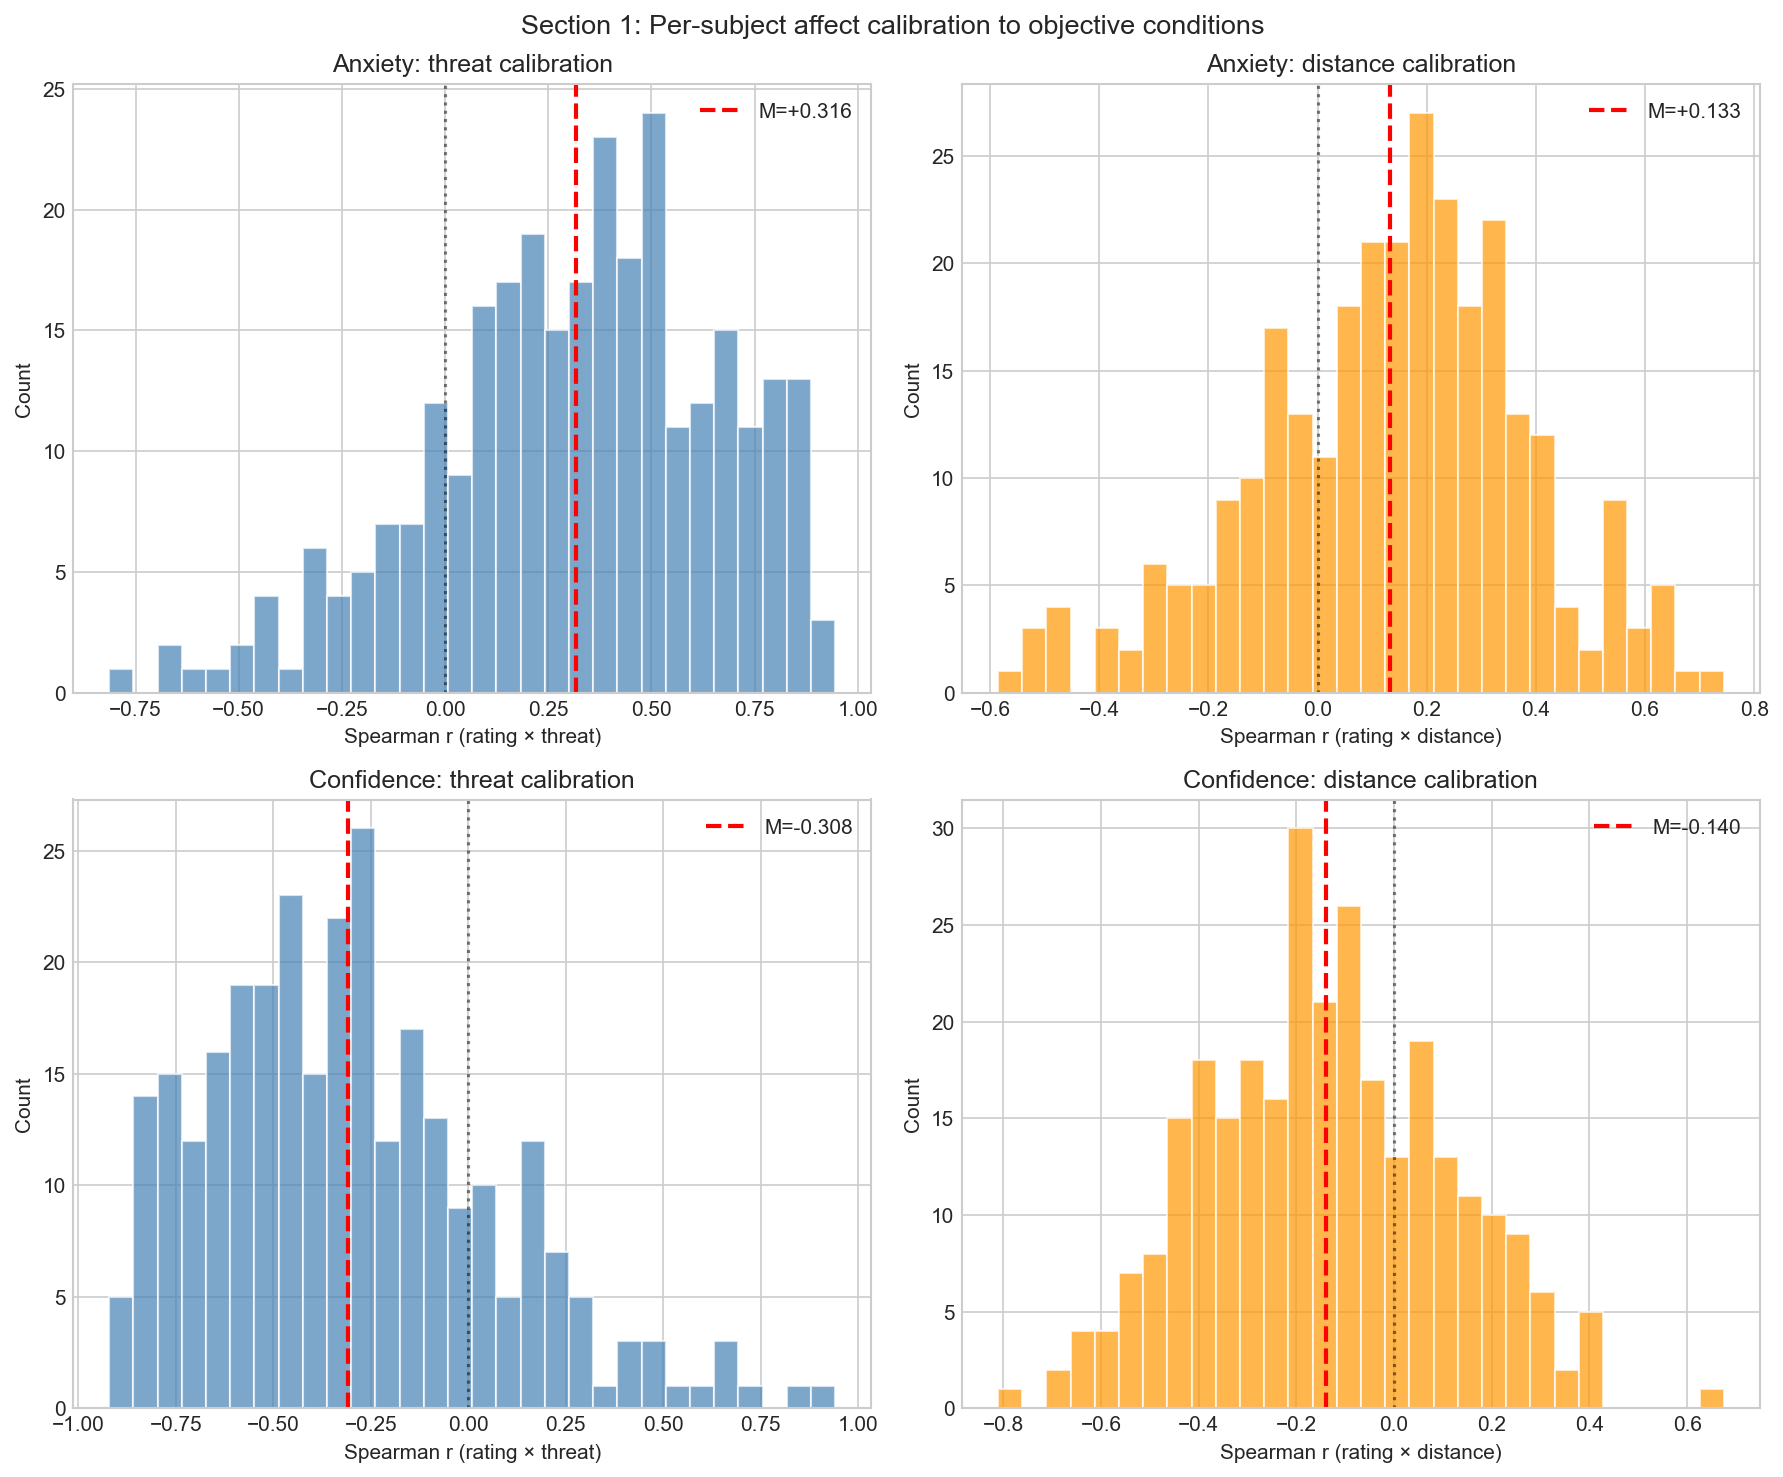

In [12]:
# ── 1. AFFECT CALIBRATION TO OBJECTIVE CONDITIONS ────────────────────────────

# Compute per-subject calibration slopes: how much does rating change per unit threat/distance?
# Use probe-level data (not linked to behavioral trials — just the probe's own conditions)

from scipy.stats import spearmanr

# Per-subject: correlate rating with probe conditions
calib_results = []
for subj, grp in feelings.groupby('subj'):
    for atype in ['anxiety', 'confidence']:
        sub = grp[grp['affect_type'] == atype]
        if len(sub) < 5:
            continue
        
        # Threat calibration: correlation between rating and probe threat
        r_threat, p_threat = spearmanr(sub['p_threat'], sub['rating'])
        
        # Distance calibration: correlation between rating and probe distance
        if 'dist_safety' in sub.columns and sub['dist_safety'].notna().sum() > 5:
            r_dist, p_dist = spearmanr(sub['dist_safety'], sub['rating'])
        else:
            r_dist, p_dist = np.nan, np.nan
        
        calib_results.append({
            'subj': subj, 'affect_type': atype,
            'r_threat': r_threat, 'p_threat': p_threat,
            'r_dist': r_dist, 'p_dist': p_dist,
            'n_probes': len(sub),
        })

calib = pd.DataFrame(calib_results)
calib = calib.merge(param_df, left_on='subj', right_index=True, how='left')

print('── Per-subject calibration (Spearman r between rating and condition) ──\n')
for atype in ['anxiety', 'confidence']:
    sub = calib[calib['affect_type'] == atype]
    print(f'  {atype.upper()} (N={len(sub)}):')
    print(f'    Threat calibration:  M(r)={sub["r_threat"].mean():+.3f}, '
          f'SD={sub["r_threat"].std():.3f}, '
          f'fraction significant (p<.05): {(sub["p_threat"]<0.05).mean():.1%}')
    print(f'    Distance calibration: M(r)={sub["r_dist"].mean():+.3f}, '
          f'SD={sub["r_dist"].std():.3f}, '
          f'fraction significant (p<.05): {(sub["p_dist"]<0.05).mean():.1%}')
    
    # Is calibration > 0 at group level?
    t, p = stats.ttest_1samp(sub['r_threat'].dropna(), 0)
    print(f'    Threat calibration > 0: t={t:.2f}, p={p:.2e}')
    t, p = stats.ttest_1samp(sub['r_dist'].dropna(), 0)
    print(f'    Distance calibration ≠ 0: t={t:.2f}, p={p:.2e}\n')

# ── Visualize calibration distributions ──
fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=DPI)

for i, atype in enumerate(['anxiety', 'confidence']):
    sub = calib[calib['affect_type'] == atype]
    
    ax = axes[i, 0]
    ax.hist(sub['r_threat'], bins=30, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(0, color='k', linestyle=':', alpha=0.5)
    ax.axvline(sub['r_threat'].mean(), color='red', linestyle='--', linewidth=2,
               label=f'M={sub["r_threat"].mean():+.3f}')
    ax.set_xlabel('Spearman r (rating × threat)')
    ax.set_ylabel('Count')
    ax.set_title(f'{atype.capitalize()}: threat calibration')
    ax.legend()
    
    ax = axes[i, 1]
    ax.hist(sub['r_dist'], bins=30, color='#FF9800', alpha=0.7, edgecolor='white')
    ax.axvline(0, color='k', linestyle=':', alpha=0.5)
    ax.axvline(sub['r_dist'].mean(), color='red', linestyle='--', linewidth=2,
               label=f'M={sub["r_dist"].mean():+.3f}')
    ax.set_xlabel('Spearman r (rating × distance)')
    ax.set_ylabel('Count')
    ax.set_title(f'{atype.capitalize()}: distance calibration')
    ax.legend()

plt.suptitle('Section 1: Per-subject affect calibration to objective conditions', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'metacog_1_calibration_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 2. Does Confidence Predict Escape? Does Anxiety Predict Capture?

**Question:** On probe trials followed by attack trials, does the person's confidence/anxiety rating predict whether they actually escape?

This is the core metacognitive accuracy test. Note: probe conditions and following trial conditions may differ, so we should look at this both raw and controlling for objective conditions.

Confidence probes with outcomes: 5,224
Anxiety probes with outcomes: 5,140
Overall success rate: 0.668
  Attack trials: 0.373 (N=2765)
  Non-attack trials: 1.000 (N=2459)



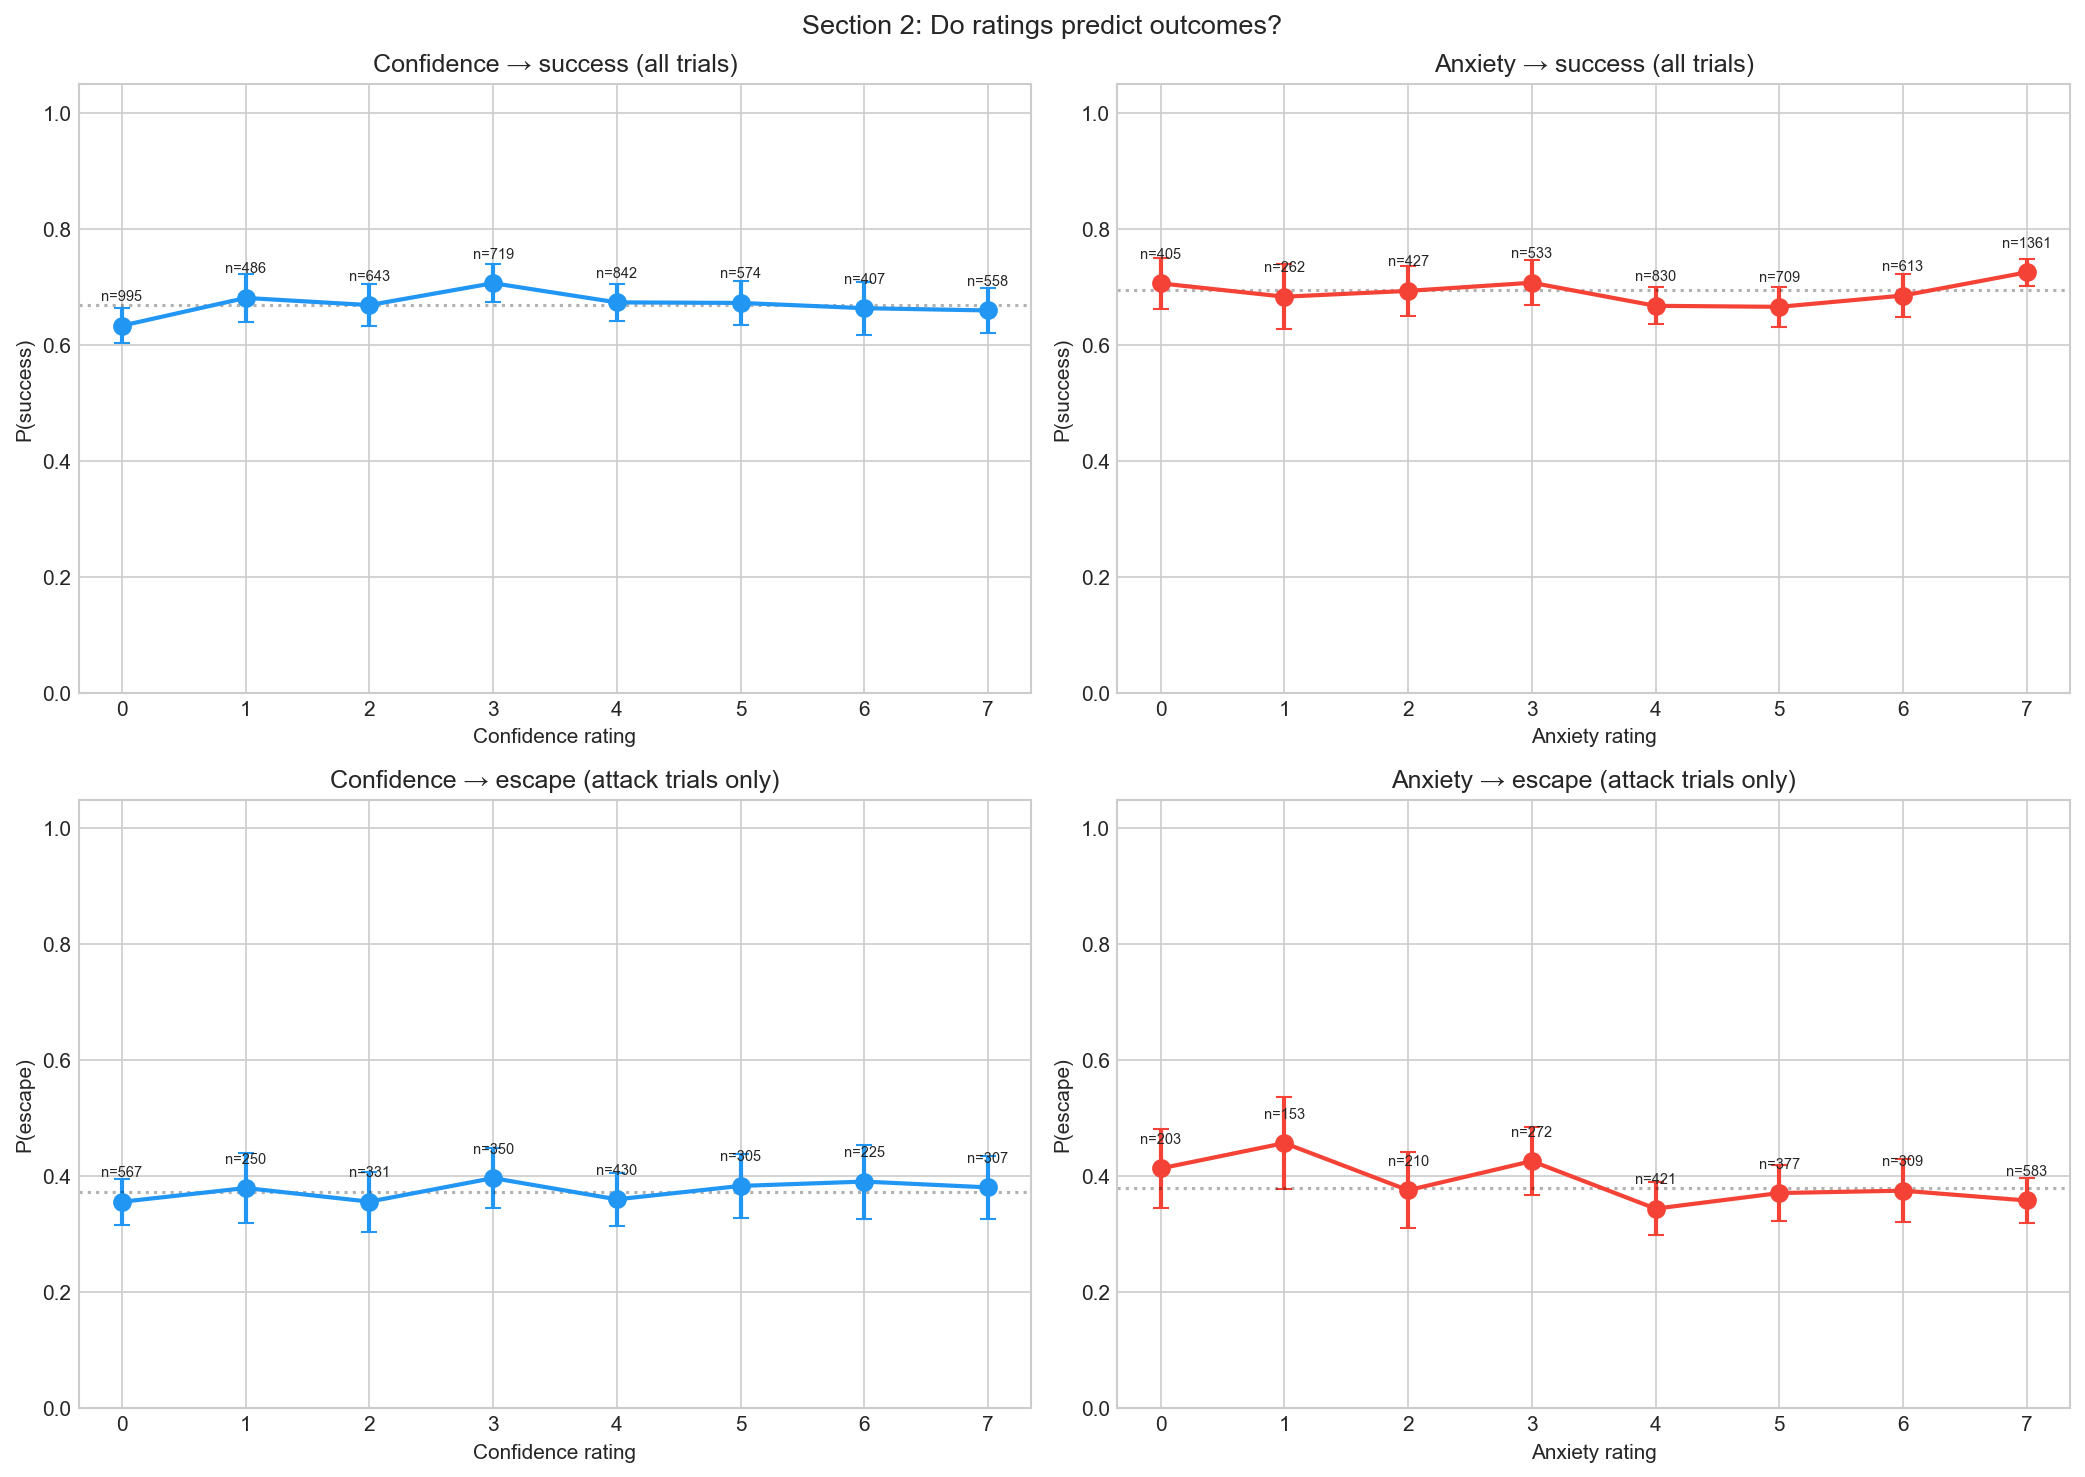

── Mixed-effects: P(success) ~ rating_z + (1|subj) ──

  All trials:
    Confidence: β=0.0117, SE=0.0070, z=1.66, p=9.63e-02
    Anxiety: β=0.0213, SE=0.0070, z=3.04, p=2.36e-03

  Attack only:
    Confidence: β=0.0220, SE=0.0091, z=2.41, p=1.61e-02
    Anxiety: β=0.0088, SE=0.0097, z=0.91, p=3.64e-01

── Controlling for probe threat + distance + following trial threat ──

  Confidence:
    rating_z: β=-0.0020, p=7.72e-01 
    fol_threat_z: β=-0.0665, p=7.85e-27 *
    probe_dist_z: β=-0.0999, p=1.22e-58 *



/opt/anaconda3/envs/effort_foraging_threat/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/effort_foraging_threat/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


  Anxiety:
    rating_z: β=0.0121, p=5.57e-02 
    fol_threat_z: β=-0.1975, p=1.28e-278 *
    probe_dist_z: β=0.0313, p=1.30e-08 *



In [13]:
# ── 2. CONFIDENCE/ANXIETY → OUTCOMES ─────────────────────────────────────────

import statsmodels.formula.api as smf

# outcome=0 means success (escaped or completed safely), outcome=1 means failure
# (captured by predator on attack trials, or timeout on non-attack trials)
# Recode: success = 1 - outcome (so higher = better, matches confidence direction)
linked_df['success'] = 1 - linked_df['outcome']
conf_df['success'] = 1 - conf_df['outcome']
anx_df['success'] = 1 - anx_df['outcome']

# Use ALL trials (attack and non-attack) since confidence should predict
# successful completion regardless of failure mode
conf_all = conf_df.dropna(subset=['success']).copy()
anx_all = anx_df.dropna(subset=['success']).copy()

print(f'Confidence probes with outcomes: {len(conf_all):,}')
print(f'Anxiety probes with outcomes: {len(anx_all):,}')
print(f'Overall success rate: {conf_all["success"].mean():.3f}')
print(f'  Attack trials: {conf_all[conf_all["isAttackTrial"]==1]["success"].mean():.3f} '
      f'(N={len(conf_all[conf_all["isAttackTrial"]==1])})')
print(f'  Non-attack trials: {conf_all[conf_all["isAttackTrial"]==0]["success"].mean():.3f} '
      f'(N={len(conf_all[conf_all["isAttackTrial"]==0])})\n')

# ── 2a. Calibration curves: P(success) by rating bin ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=DPI)

for col, (df_all, label, color) in enumerate([
    (conf_all, 'Confidence', '#2196F3'),
    (anx_all, 'Anxiety', '#F44336'),
]):
    # Top row: all trials
    ax = axes[0, col]
    cal = df_all.groupby('rating').agg(
        success_rate=('success', 'mean'),
        n=('success', 'count'),
        se=('success', 'sem'),
    ).reset_index()
    ax.errorbar(cal['rating'], cal['success_rate'], yerr=1.96*cal['se'],
                fmt='o-', color=color, markersize=8, capsize=4, linewidth=2)
    for _, row in cal.iterrows():
        ax.annotate(f'n={int(row["n"])}', (row['rating'], row['success_rate']),
                    textcoords='offset points', xytext=(0, 12), fontsize=7, ha='center')
    ax.set_xlabel(f'{label} rating')
    ax.set_ylabel('P(success)')
    ax.set_title(f'{label} → success (all trials)')
    ax.set_ylim(0, 1.05)
    ax.axhline(df_all['success'].mean(), color='k', linestyle=':', alpha=0.3)
    
    # Bottom row: attack trials only
    ax = axes[1, col]
    df_atk = df_all[df_all['isAttackTrial'] == 1]
    if len(df_atk) > 50:
        cal = df_atk.groupby('rating').agg(
            success_rate=('success', 'mean'),
            n=('success', 'count'),
            se=('success', 'sem'),
        ).reset_index()
        ax.errorbar(cal['rating'], cal['success_rate'], yerr=1.96*cal['se'],
                    fmt='o-', color=color, markersize=8, capsize=4, linewidth=2)
        for _, row in cal.iterrows():
            ax.annotate(f'n={int(row["n"])}', (row['rating'], row['success_rate']),
                        textcoords='offset points', xytext=(0, 12), fontsize=7, ha='center')
        ax.set_xlabel(f'{label} rating')
        ax.set_ylabel('P(escape)')
        ax.set_title(f'{label} → escape (attack trials only)')
        ax.set_ylim(0, 1.05)
        ax.axhline(df_atk['success'].mean(), color='k', linestyle=':', alpha=0.3)

plt.suptitle('Section 2: Do ratings predict outcomes?', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'metacog_2_calibration_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# ── 2b. LMMs ──
print('── Mixed-effects: P(success) ~ rating_z + (1|subj) ──\n')

for trial_type, trial_label in [('all', 'All trials'), ('attack', 'Attack only')]:
    print(f'  {trial_label}:')
    for label, df_base in [('Confidence', conf_all), ('Anxiety', anx_all)]:
        df = df_base.copy()
        if trial_type == 'attack':
            df = df[df['isAttackTrial'] == 1]
        if len(df) < 100:
            print(f'    {label}: insufficient data')
            continue
        
        df['rating_z'] = (df['rating'] - df['rating'].mean()) / df['rating'].std()
        
        try:
            model = smf.mixedlm('success ~ rating_z', df, groups=df['subj'])
            fit = model.fit(reml=False)
            print(f'    {label}: β={fit.params["rating_z"]:.4f}, SE={fit.bse["rating_z"]:.4f}, '
                  f'z={fit.tvalues["rating_z"]:.2f}, p={fit.pvalues["rating_z"]:.2e}')
        except Exception as e:
            r, p = stats.pointbiserialr(df['rating'], df['success'])
            print(f'    {label} (fallback): r={r:.3f}, p={p:.2e}')
    print()

# ── 2c. Controlling for objective conditions ──
print('── Controlling for probe threat + distance + following trial threat ──\n')

for label, df_base in [('Confidence', conf_all), ('Anxiety', anx_all)]:
    df = df_base.copy()
    df['rating_z'] = (df['rating'] - df['rating'].mean()) / df['rating'].std()
    df['probe_threat_z'] = (df['probe_threat'] - df['probe_threat'].mean()) / df['probe_threat'].std()
    df['fol_threat_z'] = (df['fol_threat'] - df['fol_threat'].mean()) / df['fol_threat'].std()
    if df['probe_dist'].notna().sum() > 10:
        df['probe_dist_z'] = (df['probe_dist'] - df['probe_dist'].mean()) / df['probe_dist'].std()
    else:
        df['probe_dist_z'] = 0
    
    df_clean = df.dropna(subset=['rating_z', 'success', 'fol_threat_z', 'probe_dist_z'])
    try:
        model = smf.mixedlm('success ~ rating_z + fol_threat_z + probe_dist_z', 
                            df_clean, groups='subj')
        fit = model.fit(reml=False)
        print(f'  {label}:')
        for term in ['rating_z', 'fol_threat_z', 'probe_dist_z']:
            if term in fit.params:
                sig = '*' if fit.pvalues[term] < 0.05 else ''
                print(f'    {term}: β={fit.params[term]:.4f}, p={fit.pvalues[term]:.2e} {sig}')
        print()
    except Exception as e:
        print(f'  {label}: LMM failed ({e})\n')

---
## 3. Individual Differences in Calibration Accuracy × Model Parameters

**Question:** Do model parameters predict how well-calibrated a person's affect ratings are?

For each subject, compute their calibration accuracy as the correlation between their ratings and the objective conditions. Then regress calibration accuracy on z, k, β.

**Prediction:** If z captures how well someone differentiates distance-dependent danger, high-z people should show better calibration (stronger rating × condition correlations).

── Model params → calibration accuracy ──

  ANXIETY:
    Threat calib × z: r=-0.002, p=0.969 
    Threat calib × k: r=-0.309, p=0.000 *
    Threat calib × β: r=+0.135, p=0.022 *
    Threat joint: z=+0.045, k=-0.342, β=+0.184, R²=0.121, p=0.000 *
    Distance calib × z: r=+0.152, p=0.010 *
    Distance calib × k: r=-0.018, p=0.763 
    Distance calib × β: r=+0.057, p=0.338 
    Distance joint: z=+0.166, k=-0.048, β=+0.064, R²=0.018, p=0.041 *

  CONFIDENCE:
    Threat calib × z: r=-0.014, p=0.814 
    Threat calib × k: r=-0.210, p=0.000 *
    Threat calib × β: r=+0.070, p=0.234 
    Threat joint: z=+0.018, k=-0.229, β=+0.103, R²=0.045, p=0.001 *
    Distance calib × z: r=+0.106, p=0.070 
    Distance calib × k: r=+0.032, p=0.584 
    Distance calib × β: r=-0.025, p=0.671 
    Distance joint: z=+0.103, k=+0.023, β=-0.027, R²=0.002, p=0.311 



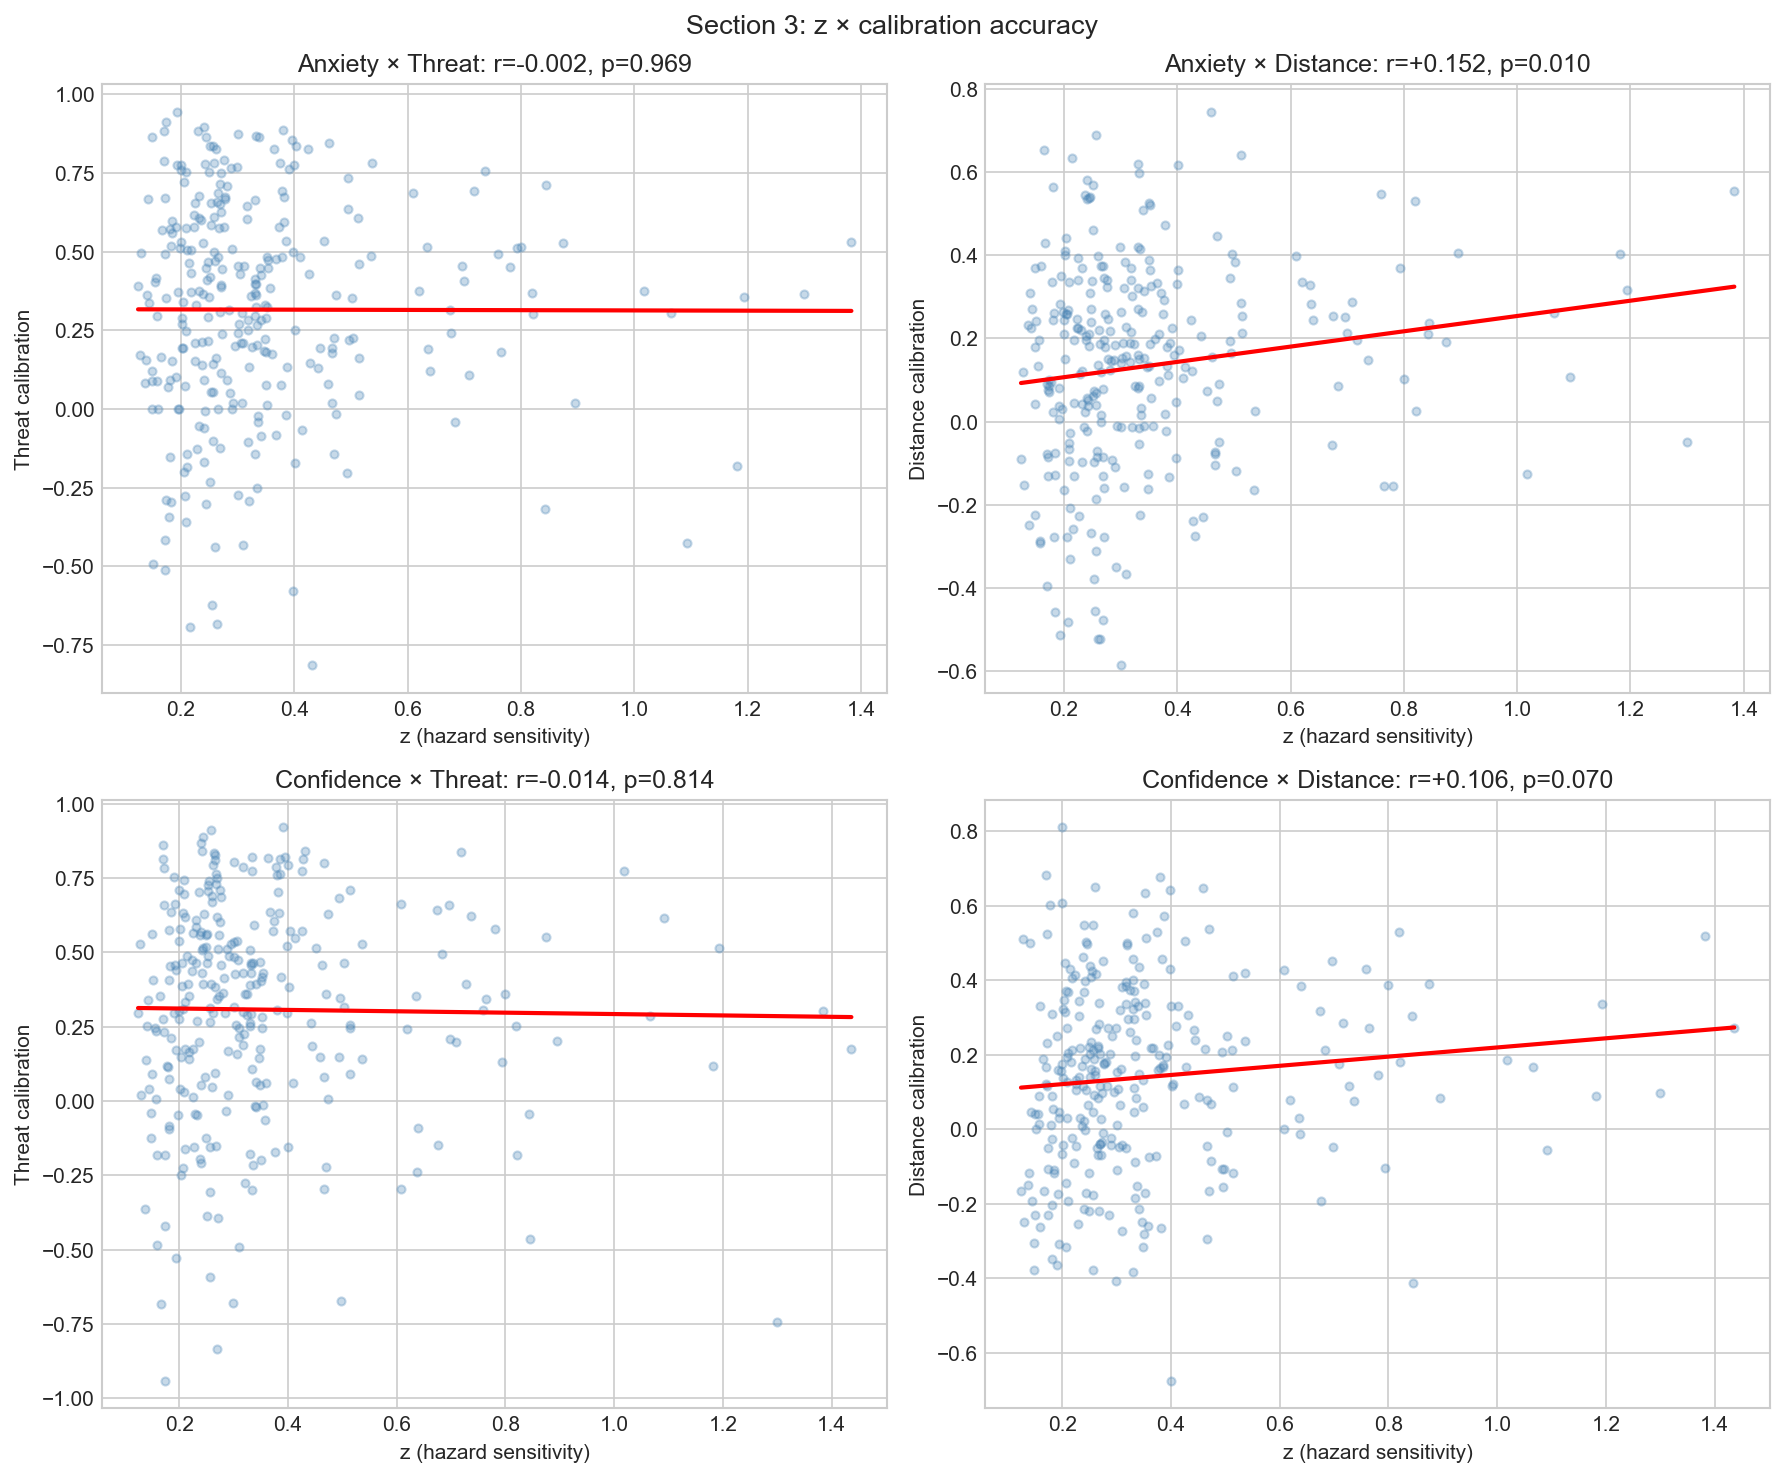

In [14]:
# ── 3. CALIBRATION ACCURACY × MODEL PARAMETERS ──────────────────────────────

from sklearn.linear_model import LinearRegression

print('── Model params → calibration accuracy ──\n')

# Compute a combined calibration score: |r_threat| (absolute sensitivity to threat)
# Higher = more calibrated (regardless of sign — anxiety should be positive, confidence negative)
for atype in ['anxiety', 'confidence']:
    sub = calib[calib['affect_type'] == atype].copy()
    
    # For anxiety: good calibration = positive r_threat (more threat → more anxiety)
    # For confidence: good calibration = negative r_threat (more threat → less confidence)
    if atype == 'anxiety':
        sub['threat_calib'] = sub['r_threat']  # should be positive
        sub['dist_calib'] = sub['r_dist']      # should be positive
    else:
        sub['threat_calib'] = -sub['r_threat'] # flip so positive = good calibration
        sub['dist_calib'] = -sub['r_dist']
    
    print(f'  {atype.upper()}:')
    
    for calib_type, calib_col in [('Threat', 'threat_calib'), ('Distance', 'dist_calib')]:
        sub_clean = sub.dropna(subset=[calib_col, 'z_z', 'kappa_z', 'beta_z'])
        if len(sub_clean) < 50:
            print(f'    {calib_type}: insufficient data')
            continue
        
        X = sub_clean[['z_z', 'kappa_z', 'beta_z']].values
        y = sub_clean[calib_col].values
        
        # Individual correlations
        for param, pidx in [('z', 0), ('k', 1), ('β', 2)]:
            r, p = stats.pearsonr(X[:, pidx], y)
            sig = '*' if p < 0.05 else ''
            print(f'    {calib_type} calib × {param}: r={r:+.3f}, p={p:.3f} {sig}')
        
        # Joint regression
        y_std = (y - y.mean()) / y.std() if y.std() > 0 else y
        reg = LinearRegression().fit(X, y_std)
        betas = reg.coef_
        y_pred = reg.predict(X)
        n = len(y); k_p = 3
        ss_res = np.sum((y_std - y_pred)**2)
        ss_tot = np.sum((y_std - y_std.mean())**2)
        adj_r2 = 1 - (1 - (1 - ss_res/ss_tot)) * (n-1) / (n-k_p-1)
        ms_reg = (ss_tot - ss_res) / k_p
        ms_res = ss_res / (n-k_p-1)
        F_stat = ms_reg / ms_res
        p_F = 1 - stats.f.cdf(F_stat, k_p, n-k_p-1)
        sig = '*' if p_F < 0.05 else ''
        print(f'    {calib_type} joint: z={betas[0]:+.3f}, k={betas[1]:+.3f}, β={betas[2]:+.3f}, '
              f'R²={adj_r2:.3f}, p={p_F:.3f} {sig}')
    print()

# ── Scatter plots: z vs calibration ──
fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=DPI)

for i, atype in enumerate(['anxiety', 'confidence']):
    sub = calib[calib['affect_type'] == atype].copy()
    if atype == 'confidence':
        sub['threat_calib'] = -sub['r_threat']
        sub['dist_calib'] = -sub['r_dist']
    else:
        sub['threat_calib'] = sub['r_threat']
        sub['dist_calib'] = sub['r_dist']
    
    for j, (calib_type, calib_col) in enumerate([('Threat', 'threat_calib'), ('Distance', 'dist_calib')]):
        ax = axes[i, j]
        clean = sub.dropna(subset=[calib_col, 'z'])
        ax.scatter(clean['z'], clean[calib_col], alpha=0.3, s=15, color='steelblue')
        
        # Regression line
        m, b = np.polyfit(clean['z'], clean[calib_col], 1)
        x_range = np.linspace(clean['z'].min(), clean['z'].max(), 100)
        ax.plot(x_range, m * x_range + b, 'r-', linewidth=2)
        
        r, p = stats.pearsonr(clean['z'], clean[calib_col])
        ax.set_xlabel('z (hazard sensitivity)')
        ax.set_ylabel(f'{calib_type} calibration')
        ax.set_title(f'{atype.capitalize()} × {calib_type}: r={r:+.3f}, p={p:.3f}')

plt.suptitle('Section 3: z × calibration accuracy', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'metacog_3_z_calibration.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 4. Model-Derived Survival as Metacognitive Ground Truth

**Question:** The FET model computes a survival probability S for each condition. Do people's affect ratings track S, and does this tracking accuracy vary with z?

This is the tightest test: S is the model's "correct" assessment of survival given threat and distance. A well-calibrated person's confidence should match S, and their anxiety should match (1 - S). z should predict how well the person's ratings align with the model's prediction.

We compute S for each probe trial using the population-level parameters, then ask:
- Does per-subject correlation(confidence, S_probe) vary?
- Does z predict this correlation?

S_probe range: [0.000, 0.888]
S_probe mean: 0.464

── Per-subject correlation(rating, S_probe) ──

  ANXIETY (N=293):
    M(r)=-0.341, SD=0.352
    r ≠ 0: t=nan, p=nan
    Calibration accuracy × z: r=+nan, p=nan 
    Calibration accuracy × k: r=+nan, p=nan 
    Calibration accuracy × β: r=+nan, p=nan 

  CONFIDENCE (N=293):
    M(r)=+0.340, SD=0.375
    r ≠ 0: t=nan, p=nan
    Calibration accuracy × z: r=+nan, p=nan 
    Calibration accuracy × k: r=+nan, p=nan 
    Calibration accuracy × β: r=+nan, p=nan 



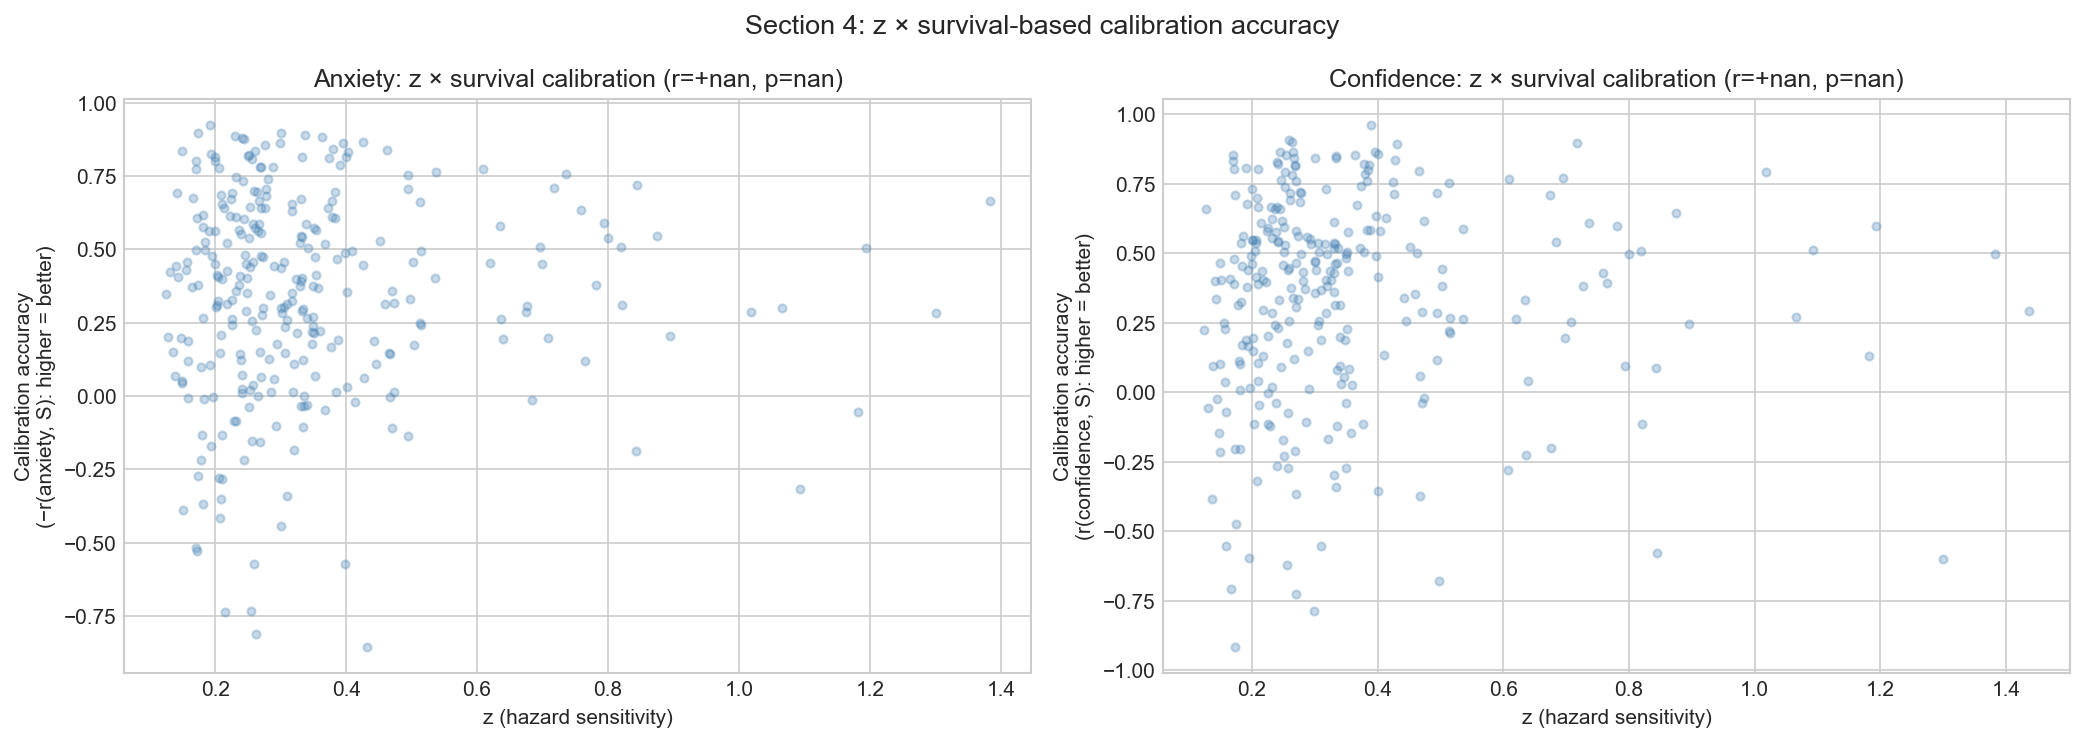

In [15]:
# ── 4. SURVIVAL-BASED METACOGNITIVE ACCURACY ─────────────────────────────────

# Compute model-derived survival for each probe trial using EACH SUBJECT'S OWN z
# S_probe = exp(-threat * dist^z_i)
# This uses the probe's threat and distance, not the following trial's

feelings_s = feelings.copy()
feelings_s = feelings_s.merge(param_df[['z', 'kappa', 'beta']], left_on='subj', right_index=True, how='left')

# Compute subject-specific survival for each probe
feelings_s['S_probe'] = np.exp(-feelings_s['p_threat'] * feelings_s['dist_safety'] ** feelings_s['z'])

print(f'S_probe range: [{feelings_s["S_probe"].min():.3f}, {feelings_s["S_probe"].max():.3f}]')
print(f'S_probe mean: {feelings_s["S_probe"].mean():.3f}\n')

# Per-subject: correlation between rating and S_probe
surv_calib = []
for subj, grp in feelings_s.groupby('subj'):
    for atype in ['anxiety', 'confidence']:
        sub = grp[grp['affect_type'] == atype].dropna(subset=['S_probe', 'rating'])
        if len(sub) < 5:
            continue
        r, p = spearmanr(sub['S_probe'], sub['rating'])
        surv_calib.append({
            'subj': subj, 'affect_type': atype,
            'r_survival': r, 'p_survival': p,
        })

surv_calib_df = pd.DataFrame(surv_calib)
surv_calib_df = surv_calib_df.merge(param_df, left_on='subj', right_index=True, how='left')

print('── Per-subject correlation(rating, S_probe) ──\n')
for atype in ['anxiety', 'confidence']:
    sub = surv_calib_df[surv_calib_df['affect_type'] == atype]
    print(f'  {atype.upper()} (N={len(sub)}):')
    print(f'    M(r)={sub["r_survival"].mean():+.3f}, SD={sub["r_survival"].std():.3f}')
    t, p = stats.ttest_1samp(sub['r_survival'], 0)
    print(f'    r ≠ 0: t={t:.2f}, p={p:.2e}')
    
    # Does z predict survival calibration?
    # For anxiety: good = negative r (high S → low anxiety)
    # For confidence: good = positive r (high S → high confidence)
    if atype == 'anxiety':
        sub = sub.copy()
        sub['calib_accuracy'] = -sub['r_survival']  # flip so positive = good
    else:
        sub = sub.copy()
        sub['calib_accuracy'] = sub['r_survival']
    
    r_z, p_z = stats.pearsonr(sub['z'].dropna(), sub.loc[sub['z'].notna(), 'calib_accuracy'])
    r_k, p_k = stats.pearsonr(sub['kappa'].dropna(), sub.loc[sub['kappa'].notna(), 'calib_accuracy'])
    r_b, p_b = stats.pearsonr(sub['beta'].dropna(), sub.loc[sub['beta'].notna(), 'calib_accuracy'])
    
    print(f'    Calibration accuracy × z: r={r_z:+.3f}, p={p_z:.3f} {"*" if p_z<0.05 else ""}')
    print(f'    Calibration accuracy × k: r={r_k:+.3f}, p={p_k:.3f} {"*" if p_k<0.05 else ""}')
    print(f'    Calibration accuracy × β: r={r_b:+.3f}, p={p_b:.3f} {"*" if p_b<0.05 else ""}')
    print()

# ── Visualization ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=DPI)

for i, atype in enumerate(['anxiety', 'confidence']):
    ax = axes[i]
    sub = surv_calib_df[surv_calib_df['affect_type'] == atype]
    
    if atype == 'anxiety':
        calib_acc = -sub['r_survival']
        ylabel = 'Calibration accuracy\n(−r(anxiety, S): higher = better)'
    else:
        calib_acc = sub['r_survival']
        ylabel = 'Calibration accuracy\n(r(confidence, S): higher = better)'
    
    ax.scatter(sub['z'], calib_acc, alpha=0.3, s=15, color='steelblue')
    clean = sub.dropna(subset=['z'])
    m, b = np.polyfit(clean['z'], calib_acc.loc[clean.index], 1)
    x_range = np.linspace(clean['z'].min(), clean['z'].max(), 100)
    ax.plot(x_range, m * x_range + b, 'r-', linewidth=2)
    
    r, p = stats.pearsonr(clean['z'], calib_acc.loc[clean.index])
    ax.set_xlabel('z (hazard sensitivity)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{atype.capitalize()}: z × survival calibration (r={r:+.3f}, p={p:.3f})')

plt.suptitle('Section 4: z × survival-based calibration accuracy', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'metacog_4_z_survival_calibration.png', dpi=300, bbox_inches='tight')
plt.show()